In [26]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
company_counts = pd.read_csv( "../src/my_notebooks/company_article_counts.csv")
graph_nodes = pd.read_csv("../src/my_notebooks/louvain_clusters_with_industries_degrees_ranks.csv")

In [27]:
print('Company couts ', list(company_counts.columns))
print('Graph nodes:', list(graph_nodes.columns))

Company couts  ['company_id', 'company', 'article_count']
Graph nodes: ['company_id', 'company', 'ticker', 'industries', 'industry_list', 'possible_industry_groups', 'industry_group', 'cluster', 'degree', 'degree_centrality', 'weighted_degree', 'betweenness', 'pagerank', 'revenue', 'market_cap']


In [ ]:

graph_nodes = graph_nodes.merge(
        company_counts[["company_id", "article_count"]],
        on="company_id",
        how="left"
    )
with_ticker = graph_nodes[
    graph_nodes["ticker"].notna()
    & graph_nodes["ticker"].astype(str).str.strip().ne("")
].copy()

with_ticker = with_ticker.drop_duplicates(subset="ticker", keep="first").copy()

tickers = sorted(with_ticker["ticker"].dropna().astype(str).str.strip().unique())

print("Loaded graph nodes:", len(graph_nodes))
print("Nodes with ticker:", len(with_ticker))
print("Columns:", list(with_ticker.columns))

with_ticker.sort_values("article_count",ascending=False).head()

Loaded graph nodes: 1172
Nodes with ticker: 1131
Columns: ['company_id', 'company', 'ticker', 'industries', 'industry_list', 'possible_industry_groups', 'industry_group', 'cluster', 'degree', 'degree_centrality', 'weighted_degree', 'betweenness', 'pagerank', 'revenue', 'market_cap', 'article_count']


,company_id,company,ticker,industries,industry_list,possible_industry_groups,industry_group,cluster,degree,degree_centrality,weighted_degree,betweenness,pagerank,revenue,market_cap,article_count
0,Q312,Apple Inc.,AAPL,software development; digital distribution; so...,"['software development', 'digital distribution...",['Technology / Telecom'],Technology / Telecom,0,234,0.199829,1126,0.433388,0.023396,4.161610e+11,3.205000e+12,684
2,Q3884,Amazon,AMZN,retail; e-commerce; web service; web hosting s...,"['retail', 'e-commerce', 'web service', 'web h...","['Consumer / Retail / Food', 'Technology / Tel...",Technology / Telecom,0,200,0.170794,979,0.392921,0.020163,7.169240e+11,2.018000e+12,587
1,Q95,Google,GOOGL,Internet; information technology; internet mar...,"['internet', 'information technology', 'intern...","['Professional Services', 'Technology / Telecom']",Technology / Telecom,0,178,0.152007,910,0.213066,0.018174,NaN,NaN,515
24,Q66,Boeing,BA,weapons industry; aircraft construction; aircr...,"['weapons industry', 'aircraft construction', ...","['Industrials / Aerospace / Defense', 'Other /...",Industrials / Aerospace / Defense,9,123,0.105038,366,0.119243,0.008689,6.651700e+10,1.809130e+11,434
5,Q193326,Goldman Sachs,GS,financial services; International Standard Ind...,"['financial services', 'international standard...",['Finance'],Finance,8,193,0.164816,684,0.061768,0.014179,5.351200e+10,9.170000e+10,409


# Pull prices from yfinance

In [ ]:
import yfinance as yf

START, END = "2017-01-01", "2019-12-31"
TRADING_DAYS = 252


tickers = sorted(with_ticker["ticker"].dropna().unique())

print(f"Downloading financial data for {len(tickers)} tickers...")

raw = yf.download(
    tickers,
    start=START,
    end=END,
    progress=False,
    auto_adjust=True,
    group_by="ticker",
    threads=True,
)

returns = {}
summary_rows = []

for t in tickers:
    try:
        if isinstance(raw.columns, pd.MultiIndex):
            close = raw[t]["Close"].dropna()
        else:
            close = raw["Close"].dropna()
    except KeyError:
        continue

    if len(close) < 100:
        continue

    log_ret = np.log(close).diff().dropna()
    returns[t] = log_ret

    summary_rows.append({
        "ticker": t,
        "n_obs": int(len(log_ret)),
        "vol_annualised": float(log_ret.std() * np.sqrt(TRADING_DAYS)),
        "cum_return": float(np.exp(log_ret.sum()) - 1),
        "mean_daily_ret": float(log_ret.mean()),
        "sharpe_proxy": float(
            log_ret.mean() / (log_ret.std() + 1e-12) * np.sqrt(TRADING_DAYS)
        ),
    })

fin = pd.DataFrame(summary_rows)

returns_df = pd.concat(returns, axis=1).sort_index()

if isinstance(returns_df.columns, pd.MultiIndex):
    returns_df.columns = returns_df.columns.get_level_values(0)

fin = fin.merge(
    with_ticker[
        [
            "ticker",
            "company_id",
            "company",
            "cluster",
            "industry_group",
            "industries",
            "weighted_degree",
            "degree",
            "degree_centrality",
            "pagerank",
            "betweenness",
            "article_count",
        ]
    ],
    on="ticker",
    how="left"
)

fin["sector"] = fin["industry_group"]
fin["sector_coarse"] = fin["industry_group"]

fin.to_csv("company_financials.csv", index=False)
returns_df.to_csv("daily_returns_2017_2019.csv")

print("Saved company_financials.csv:", fin.shape)
print("Saved daily_returns_2017_2019.csv:", returns_df.shape)

fin.head()

$SHOR: possibly delisted; no price data found  (1d 2017-01-01 -> 2019-12-31)
$SDRL: possibly delisted; no price data found  (1d 2017-01-01 -> 2019-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1577768400")
$SI: possibly delisted; no price data found  (1d 2017-01-01 -> 2019-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1577768400")
$AMAG: possibly delisted; no timezone found
$MMP: possibly delisted; no timezone found
$EMC: possibly delisted; no price data found  (1d 2017-01-01 -> 2019-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1577768400")
$GFS: possibly delisted; no price data found  (1d 2017-01-01 -> 2019-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1577768400")
$ZUO: possibly delisted; no timezone found
$MTU: possibly delisted; no price data found  (1d 2017-01-01 -> 2019-12-31)
$WBA: possibly delisted; no timezone found
$FCAU: possibly delisted; 

Saved company_financials.csv: (770, 19)
Saved daily_returns_2017_2019.csv: (752, 767)


,ticker,n_obs,vol_annualised,cum_return,mean_daily_ret,sharpe_proxy,company_id,company,cluster,industry_group,industries,weighted_degree,degree,degree_centrality,pagerank,betweenness,article_count,sector,sector_coarse
0,AA,752,0.409933,-0.259799,-0.000400,-0.245921,Q135325,Alcoa,9,Materials / Mining / Chemicals,Aluminium production; aluminium industry,18,11,0.009394,0.000581,0.000006,15,Materials / Mining / Chemicals,Materials / Mining / Chemicals
1,AAPL,752,0.247422,1.627399,0.001285,1.308334,Q312,Apple Inc.,0,Technology / Telecom,software development; digital distribution; so...,1126,234,0.199829,0.023396,0.433388,684,Technology / Telecom,Technology / Telecom
2,AB,752,0.216490,0.651029,0.000667,0.776119,Q4732268,AllianceBernstein,7,Finance,asset management,4,4,0.003416,0.000238,0.000000,5,Finance,Finance
3,ABBV,752,0.279450,0.613763,0.000636,0.573882,Q14662364,AbbVie,11,Healthcare,biotechnology; pharmaceutical industry,8,7,0.005978,0.000346,0.000000,5,Healthcare,Healthcare
4,ABT,752,0.191195,1.354455,0.001139,1.500847,Q306764,Abbott Laboratories,11,Healthcare,medical technology industry,23,19,0.016225,0.000958,0.000151,16,Healthcare,Healthcare


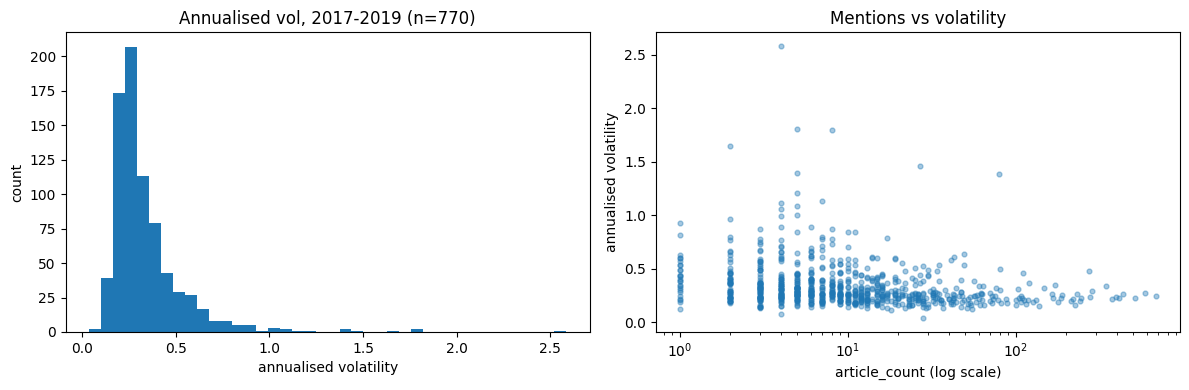

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fin["vol_annualised"].dropna(), bins=40)
axes[0].set_xlabel("annualised volatility")
axes[0].set_ylabel("count")
axes[0].set_title(
    f"Annualised vol, 2017-2019 (n={fin['vol_annualised'].notna().sum()})"
)

good = fin.dropna(subset=["article_count", "vol_annualised"])

axes[1].scatter(good["article_count"], good["vol_annualised"], alpha=0.4, s=12)
axes[1].set_xscale("log")
axes[1].set_xlabel("article_count (log scale)")
axes[1].set_ylabel("annualised volatility")
axes[1].set_title("Mentions vs volatility")

plt.tight_layout()
plt.show()